**Similarity / Retrieval Lead**

Input (loaded from 02_Embeddings/ and 01_Processed_Data/):
- 01_Processed_Data/metadata.csv
- 02_Embeddings/audio_ib_embeddings.npy   (ImageBind audio,   shape (150, 1024), float32)
- 02_Embeddings/audio_embeddings_MERT.npy (MERT audio,         shape (150,  768), float32)
- 02_Embeddings/image_ib_embeddings.npy   (ImageBind image,   shape (150, 1024), float32)
- 02_Embeddings/image_clip_embeddings.npy (CLIP image,         shape (150,  512), float32)
- 02_Embeddings/text_ib_embeddings.npy    (ImageBind text,     shape (150, 1024), float32)
- 02_Embeddings/text_clap_embeddings.npy  (CLAP text,          shape (150,  512), float32)

Output (saved to 03_Final_Results/ and 04_Visual_Checks/):
- 03_Final_Results/final_similarity_report.csv  — metadata.csv + per-track congruence columns
- 03_Final_Results/category_performance.csv     — emotion_category × mean congruence
- 03_Final_Results/subcategory_performance.csv  — emotion_subcategory × mean congruence
- 03_Final_Results/generalist_vs_specialist.csv — CKA / RSA / Procrustes across IB-vs-specialist per modality
- 03_Final_Results/retrieval_recall.csv         — Recall@{1,5,10} for four cross-modal retrievals
- 03_Final_Results/similarity_heatmap.png       — canonical audio↔image heatmap
- 04_Visual_Checks/05_{timestamp}/              — seeded heatmaps + diag-vs-offdiag histograms

Research question: Does the generalist (ImageBind) cluster the 150 tracks the same way the
modality-specialists (MERT / CLIP / CLAP) do? Cosine answers pair-level questions;
CKA / RSA / Procrustes answer the space-vs-space question.


Run all once notebook 2,3,4 processing are complete.

In [ ]:
# =====================================================================
# Cell 2 — Setup, constants, seeding, archive primitives
# =====================================================================
from google.colab import drive
import os, shutil, random
from datetime import datetime

import numpy as np
import pandas as pd
import torch
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA
from scipy.spatial.distance import pdist
from scipy.stats import spearmanr, zscore
from scipy.linalg import orthogonal_procrustes

drive.mount("/content/drive")

# --- Project structure (canonical) ---
PROJECT_ROOT   = "/content/drive/MyDrive/DL_Project_2026"
PROCESSED_DIR  = os.path.join(PROJECT_ROOT, "01_Processed_Data")
EMBED_DIR      = os.path.join(PROJECT_ROOT, "02_Embeddings")
RESULTS_DIR    = os.path.join(PROJECT_ROOT, "03_Final_Results")
VIS_DIR        = os.path.join(PROJECT_ROOT, "04_Visual_Checks")
VERSIONS_ROOT  = os.path.join(PROJECT_ROOT, "99_Versions")

os.makedirs(RESULTS_DIR, exist_ok=True)   # F-10: guarantee before CSV writes
os.makedirs(VIS_DIR,     exist_ok=True)
os.makedirs(VERSIONS_ROOT, exist_ok=True)

# --- Notebook identity + determinism (D-7) ---
NOTEBOOK_ID = "05"

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# --- Archive primitives (D-1, D-2, D-3) ---
#   archive_previous_run is retained for completeness / single-writer directories.
#   archive_files is the file-scoped primitive used in this notebook — it only moves
#   the specific files 05 owns, so sibling outputs in RESULTS_DIR (sentiment_results.csv
#   from nb04, UMAPs from nb06) are not disturbed.

def archive_previous_run(directory_path, notebook_id):
    """Move the *entire* directory into 99_Versions/{notebook_id}_{stamp}_{folder}/."""
    if os.path.exists(directory_path) and os.listdir(directory_path):
        stamp = datetime.now().strftime("%Y-%m-%d_%H-%M")
        folder_name = os.path.basename(directory_path.rstrip("/"))
        archive_name = os.path.join(
            VERSIONS_ROOT, f"{notebook_id}_{stamp}_{folder_name}"
        )
        print(f"📦 Archiving {directory_path} → {archive_name}")
        shutil.move(directory_path, archive_name)
    os.makedirs(directory_path, exist_ok=True)

def archive_files(file_paths, notebook_id):
    """Move only `file_paths` that exist into 99_Versions/{id}_{stamp}_{parent}/."""
    movers = [p for p in file_paths if os.path.exists(p)]
    if not movers:
        return
    stamp = datetime.now().strftime("%Y-%m-%d_%H-%M")
    parent_name = os.path.basename(os.path.dirname(movers[0]))
    out_dir = os.path.join(VERSIONS_ROOT, f"{notebook_id}_{stamp}_{parent_name}")
    os.makedirs(out_dir, exist_ok=True)
    for p in movers:
        shutil.move(p, os.path.join(out_dir, os.path.basename(p)))
    print(f"📦 Archived {len(movers)} file(s) → {out_dir}")

print(f"✅ Setup complete | NOTEBOOK_ID={NOTEBOOK_ID} | seed={SEED}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Setup complete | NOTEBOOK_ID=05 | seed=42


In [ ]:
# =====================================================================
# Cell 3 — Upstream contract check (F-5)
# =====================================================================
# Asserts the shapes / dtypes / finiteness of every load-bearing embedding
# file before any similarity is computed. A silent row-alignment bug upstream
# (e.g. MERT skipping a track, or a NaN from a dead audio file) would otherwise
# poison every cosine below.

REQUIRED_COLS = [
    "track_id", "song_title", "artist_name", "genre",
    "emotion_category", "emotion_subcategory",
    "file_name", "standardized_audio_path", "standardized_image_path",
    "lyrics_path",
]

meta_path = os.path.join(PROCESSED_DIR, "metadata.csv")
assert os.path.exists(meta_path), f"metadata.csv missing at {meta_path}"
metadata = pd.read_csv(meta_path)
for c in REQUIRED_COLS:
    assert c in metadata.columns, f"metadata.csv missing required column {c!r}"
assert metadata["track_id"].is_unique, "metadata.csv: track_id must be unique"

N = len(metadata)

# Load the six load-bearing embedding files.
#
# audio_clap_embeddings.npy is intentionally NOT loaded here: no notebook in
# the pipeline produces it (see 05 triage, ASK A-1). We use ImageBind for the
# audio↔text bridge instead, which keeps every cosine on the same scale and
# avoids a FileNotFoundError on first run.
audio_ib   = np.load(os.path.join(EMBED_DIR, "audio_ib_embeddings.npy"))
audio_mert = np.load(os.path.join(EMBED_DIR, "audio_embeddings_MERT.npy"))
image_ib   = np.load(os.path.join(EMBED_DIR, "image_ib_embeddings.npy"))
image_clip = np.load(os.path.join(EMBED_DIR, "image_clip_embeddings.npy"))
text_ib    = np.load(os.path.join(EMBED_DIR, "text_ib_embeddings.npy"))
text_clap  = np.load(os.path.join(EMBED_DIR, "text_clap_embeddings.npy"))

expected = {
    "audio_ib":   (audio_ib,   1024),
    "audio_mert": (audio_mert,  768),
    "image_ib":   (image_ib,   1024),
    "image_clip": (image_clip,  512),
    "text_ib":    (text_ib,    1024),
    "text_clap":  (text_clap,   512),
}
for name, (arr, d) in expected.items():
    assert arr.shape == (N, d), f"{name}: got {arr.shape}, expected ({N}, {d})"
    assert arr.dtype == np.float32, f"{name}: dtype is {arr.dtype}, expected float32"
    assert np.isfinite(arr).all(), f"{name}: contains NaN/Inf"

print(f"✅ Upstream contract OK | N={N} tracks | 6 embedding matrices validated")
for name, (arr, d) in expected.items():
    print(f"   {name:10s}  shape={arr.shape}  dtype={arr.dtype}")


✅ Upstream contract OK | N=150 tracks | 6 embedding matrices validated
   audio_ib    shape=(150, 1024)  dtype=float32
   audio_mert  shape=(150, 768)  dtype=float32
   image_ib    shape=(150, 1024)  dtype=float32
   image_clip  shape=(150, 512)  dtype=float32
   text_ib     shape=(150, 1024)  dtype=float32
   text_clap   shape=(150, 512)  dtype=float32


In [ ]:
# =====================================================================
# Cell 4 — Cross-modal cosine similarities (congruence triangle)
# =====================================================================
# All bridges use ImageBind (the generalist) so both congruence columns live
# on the same cosine scale. This is the key change vs. the original notebook,
# which mixed ImageBind cosine (audio↔image) with CLAP cosine (audio↔text) and
# averaged them — an average of distributions from two different models.
#
# Note: sklearn.metrics.pairwise.cosine_similarity L2-normalizes internally, so
# the unnormalized embeddings saved by notebooks 02/03/04 are correct here.
# Do NOT replace this with X @ Y.T unless you also L2-normalize first — every
# cosine number will silently change.

# --- A. Audio ↔ Image congruence (ImageBind ↔ ImageBind) ---
sim_audio_image = cosine_similarity(audio_ib, image_ib)
metadata["congruence_audio_visual"] = np.diag(sim_audio_image)

# --- B. Audio ↔ Text  congruence (ImageBind ↔ ImageBind) ---
#    Original notebook used CLAP audio × CLAP text here, but audio_clap does not
#    exist upstream. Using ImageBind for both sides keeps the scale identical to
#    the audio-visual bridge above. See triage ASK A-1 for the CLAP alternative.
sim_audio_text = cosine_similarity(audio_ib, text_ib)
metadata["congruence_audio_lyric"] = np.diag(sim_audio_text)

# --- C. Master congruence ---
# Raw mean (both scores are on the same IB-cosine scale, so this is defensible).
metadata["master_congruence"] = (
    metadata["congruence_audio_visual"] + metadata["congruence_audio_lyric"]
) / 2

# Robustness variant: per-column z-score before averaging, so a run with unusually
# high or low medians on one arm does not swing the combined metric.
metadata["z_audio_visual"] = zscore(metadata["congruence_audio_visual"], nan_policy="omit")
metadata["z_audio_lyric"]  = zscore(metadata["congruence_audio_lyric"],  nan_policy="omit")
metadata["master_congruence_z"] = (metadata["z_audio_visual"] + metadata["z_audio_lyric"]) / 2

# --- Archive-then-save (D-2) ---
# File-scoped: only the five CSVs 05 owns. Does NOT touch sentiment_results.csv
# from notebook 04 or any future notebook-06 artifacts in RESULTS_DIR.
final_report_path   = os.path.join(RESULTS_DIR, "final_similarity_report.csv")
cat_perf_path       = os.path.join(RESULTS_DIR, "category_performance.csv")
subcat_perf_path    = os.path.join(RESULTS_DIR, "subcategory_performance.csv")
gen_vs_spec_path    = os.path.join(RESULTS_DIR, "generalist_vs_specialist.csv")
retrieval_path      = os.path.join(RESULTS_DIR, "retrieval_recall.csv")
heatmap_results_png = os.path.join(RESULTS_DIR, "similarity_heatmap.png")

archive_files(
    [final_report_path, cat_perf_path, subcat_perf_path,
     gen_vs_spec_path, retrieval_path, heatmap_results_png],
    notebook_id=NOTEBOOK_ID,
)

# Save the enriched metadata here (F-12 — save co-located with computation).
metadata.to_csv(final_report_path, index=False)

print(f"📐 Congruence triangle computed | N={N}")
print(f"   congruence_audio_visual  mean={metadata['congruence_audio_visual'].mean():.4f}  std={metadata['congruence_audio_visual'].std():.4f}")
print(f"   congruence_audio_lyric   mean={metadata['congruence_audio_lyric'].mean():.4f}  std={metadata['congruence_audio_lyric'].std():.4f}")
print(f"   master_congruence        mean={metadata['master_congruence'].mean():.4f}")
print(f"✅ Saved {os.path.basename(final_report_path)}")


📦 Archived 6 file(s) → /content/drive/MyDrive/DL_Project_2026/99_Versions/05_2026-04-26_22-04_03_Final_Results
📐 Congruence triangle computed | N=150
   congruence_audio_visual  mean=0.1796  std=0.0668
   congruence_audio_lyric   mean=0.1382  std=0.0608
   master_congruence        mean=0.1589
✅ Saved final_similarity_report.csv


In [ ]:
# =====================================================================
# Cell 5 — Generalist vs. specialist: CKA / RSA / Procrustes (F-2)
# =====================================================================
# The research question "does ImageBind cluster the 150 tracks the same way MERT /
# CLIP / CLAP do?" is a space-vs-space question, not a pair-vs-pair question.
# Cosine answers pair-level ("is track i's audio close to track i's image?").
# CKA / RSA / Procrustes answer space-level ("do these two embedding spaces
# organize the same set of points the same way?").

def _l2_normalize(X, eps=1e-12):
    return X / (np.linalg.norm(X, axis=1, keepdims=True) + eps)

def cka_linear(X, Y):
    """Linear Centered Kernel Alignment for (N, dx) and (N, dy)."""
    X = X - X.mean(axis=0, keepdims=True)
    Y = Y - Y.mean(axis=0, keepdims=True)
    num = np.linalg.norm(X.T @ Y, ord="fro") ** 2
    den = np.linalg.norm(X.T @ X, ord="fro") * np.linalg.norm(Y.T @ Y, ord="fro")
    return float(num / (den + 1e-12))

def rsa_spearman(X, Y, metric="cosine"):
    """Spearman correlation of pairwise-distance vectors — Representational Similarity."""
    dx = pdist(X, metric=metric)
    dy = pdist(Y, metric=metric)
    return float(spearmanr(dx, dy).correlation)

def procrustes_r2(X, Y):
    """Orthogonal Procrustes goodness-of-fit after PCA-reducing both to common rank."""
    d = min(X.shape[1], Y.shape[1], X.shape[0] - 1)   # cap at N-1 for stability
    Xp = PCA(n_components=d, random_state=SEED).fit_transform(X)
    Yp = PCA(n_components=d, random_state=SEED).fit_transform(Y)
    R, _ = orthogonal_procrustes(Xp, Yp)
    resid = np.linalg.norm(Xp @ R - Yp) ** 2
    total = np.linalg.norm(Yp - Yp.mean(axis=0, keepdims=True)) ** 2
    return float(1.0 - resid / (total + 1e-12))

# L2-normalize each matrix once; CKA is scale-invariant but RSA-cosine and
# Procrustes both like unit-norm rows.
pairs = [
    ("audio: ImageBind vs MERT", _l2_normalize(audio_ib), _l2_normalize(audio_mert)),
    ("image: ImageBind vs CLIP", _l2_normalize(image_ib), _l2_normalize(image_clip)),
    ("text:  ImageBind vs CLAP", _l2_normalize(text_ib),  _l2_normalize(text_clap)),
]

rows = []
for name, gen, spec in pairs:
    rows.append({
        "comparison":     name,
        "CKA_linear":     cka_linear(gen, spec),
        "RSA_spearman":   rsa_spearman(gen, spec, metric="cosine"),
        "Procrustes_R2":  procrustes_r2(gen, spec),
        "gen_shape":      str(gen.shape),
        "spec_shape":     str(spec.shape),
    })

gen_vs_spec = pd.DataFrame(rows)
gen_vs_spec.to_csv(gen_vs_spec_path, index=False)

print("🔬 Generalist-vs-specialist comparison")
print(gen_vs_spec.to_string(index=False))
print(f"✅ Saved {os.path.basename(gen_vs_spec_path)}")


🔬 Generalist-vs-specialist comparison
              comparison  CKA_linear  RSA_spearman  Procrustes_R2   gen_shape spec_shape
audio: ImageBind vs MERT    0.550752      0.414423      -1.210820 (150, 1024) (150, 768)
image: ImageBind vs CLIP    0.756272      0.348269       0.806860 (150, 1024) (150, 512)
text:  ImageBind vs CLAP    0.456225      0.399834       0.345132 (150, 1024) (150, 512)
✅ Saved generalist_vs_specialist.csv


In [ ]:
# =====================================================================
# Cell 6 — Cross-modal retrieval, Recall@{1,5,10} (F-3)
# =====================================================================
# "Retrieval" is in this notebook's title; until now the pipeline only used the
# diagonal of the cross-modal cosine matrix and discarded off-diagonals. Recall@K
# is the standard retrieval metric: for each query, rank all candidates and check
# whether the true partner is in the top K.

def recall_at_k(sim, k):
    """sim[i,j] = similarity(query i, candidate j); diagonal is the true pair."""
    N = sim.shape[0]
    topk_idx = np.argsort(-sim, axis=1)[:, :k]
    hits = np.array([i in topk_idx[i] for i in range(N)])
    return float(hits.mean())

# Cross-modal pairs (all ImageBind-mediated — same space, so cosine is valid)
sim_image_audio = sim_audio_image.T                         # (image → audio)
sim_text_audio  = sim_audio_text.T                          # (text  → audio)

retrieval_rows = []
for name, sim in [
    ("audio → image (ImageBind)", sim_audio_image),
    ("image → audio (ImageBind)", sim_image_audio),
    ("audio → text  (ImageBind)", sim_audio_text),
    ("text  → audio (ImageBind)", sim_text_audio),
]:
    retrieval_rows.append({
        "query_target": name,
        "R@1":  recall_at_k(sim, 1),
        "R@5":  recall_at_k(sim, 5),
        "R@10": recall_at_k(sim, 10),
        "N":    int(sim.shape[0]),
        "chance_R@1":  1.0 / sim.shape[0],
        "chance_R@5":  5.0 / sim.shape[0],
        "chance_R@10": 10.0 / sim.shape[0],
    })

retrieval_df = pd.DataFrame(retrieval_rows)
retrieval_df.to_csv(retrieval_path, index=False)

print("🎯 Cross-modal retrieval")
print(retrieval_df[["query_target", "R@1", "R@5", "R@10", "chance_R@10"]].to_string(index=False))
print(f"✅ Saved {os.path.basename(retrieval_path)}")


🎯 Cross-modal retrieval
             query_target      R@1      R@5     R@10  chance_R@10
audio → image (ImageBind) 0.086667 0.206667 0.340000     0.066667
image → audio (ImageBind) 0.066667 0.206667 0.326667     0.066667
audio → text  (ImageBind) 0.040000 0.106667 0.146667     0.066667
text  → audio (ImageBind) 0.013333 0.106667 0.173333     0.066667
✅ Saved retrieval_recall.csv


In [ ]:
# =====================================================================
# Cell 7 — Failure cases + category / subcategory leaderboards (F-6, F-8)
# =====================================================================

# Guard: nsmallest silently drops NaN rows, which would hide the most pathological
# tracks (the ones with NaN congruence from an upstream NaN embedding).
na = metadata[metadata["congruence_audio_visual"].isna() | metadata["congruence_audio_lyric"].isna()]
assert na.empty, (
    f"{len(na)} tracks have NaN congruence — upstream embedding issue:\n"
    f"{na[['track_id', 'song_title']].to_string(index=False)}"
)

# --- 1. Top-5 dissonance (audio ↔ image) ---
failures = metadata.nsmallest(5, "congruence_audio_visual")
print("🚨 TOP 5 DISSONANCE CASES (audio ↔ image, lowest IB cosine):")
print(failures[["track_id", "song_title", "artist_name",
                "congruence_audio_visual", "congruence_audio_lyric",
                "master_congruence"]].to_string(index=False))

# --- 2. Category leaderboard — consumed by notebook 06 as category_performance.csv ---
cat_perf = (
    metadata
    .groupby("emotion_category")[["congruence_audio_visual",
                                   "congruence_audio_lyric",
                                   "master_congruence"]]
    .agg(["mean", "std", "count"])
)
# Flatten MultiIndex columns: ('master_congruence','mean') -> 'master_congruence_mean'
cat_perf.columns = [f"{a}_{b}" for a, b in cat_perf.columns]
cat_perf = cat_perf.reset_index()
cat_perf.to_csv(cat_perf_path, index=False)

# --- 3. Subcategory leaderboard — consumed by notebook 06 as subcategory_performance.csv ---
subcat_perf = (
    metadata
    .groupby(["emotion_category", "emotion_subcategory"])[["congruence_audio_visual",
                                                            "congruence_audio_lyric",
                                                            "master_congruence"]]
    .agg(["mean", "std", "count"])
)
subcat_perf.columns = [f"{a}_{b}" for a, b in subcat_perf.columns]
subcat_perf = subcat_perf.reset_index()
subcat_perf.to_csv(subcat_perf_path, index=False)

print("\n📊 CATEGORY mean congruence (subset):")
print(cat_perf.set_index("emotion_category")["master_congruence_mean"].sort_values(ascending=False).to_string())
print(f"\n✅ Saved {os.path.basename(cat_perf_path)} and {os.path.basename(subcat_perf_path)}")


🚨 TOP 5 DISSONANCE CASES (audio ↔ image, lowest IB cosine):
 track_id    song_title                artist_name  congruence_audio_visual  congruence_audio_lyric  master_congruence
track_091 moon and back                       JVKE                 0.027105                0.189319           0.108212
track_047         drunk                      keshi                 0.034236                0.134350           0.084293
track_023     Best Part Daniel Caesar feat. H.E.R.                 0.039636                0.173351           0.106493
track_093          Myth                Beach House                 0.040097                0.021606           0.030851
track_066     HYPNOTIZE                         XG                 0.046198                0.209032           0.127615

📊 CATEGORY mean congruence (subset):
emotion_category
Tension, Threat & Aggression         0.178665
Tender & Intimacy                    0.177139
Sadness, Loss & Lament               0.154242
Awe, Beauty & Transcendence      

PLOT 1  |  Audio ↔ Image cosine heatmap (ImageBind, 50/150 tracks)
What you're looking at:
  Rows = audio queries.  Cols = image candidates.
  Cell (i, j) = cosine between audio_ib[i] and image_ib[j] for the same
  50-track random sample.

How to read it:
  - The DIAGONAL (i = j) is the cosine for TRUE pairs (same track).
  - Off-diagonal is MISMATCHED pairs (audio of track A vs image of track B).
  - Brighter yellow = higher cosine.

Healthy signal: a visible yellow diagonal stripe on a darker background.
Pathology: uniform color, bright vertical/horizontal stripes (a track that
'matches everything' usually indicates a near-zero or degenerate embedding),
or a diagonal DARKER than the surroundings (model is actively wrong).



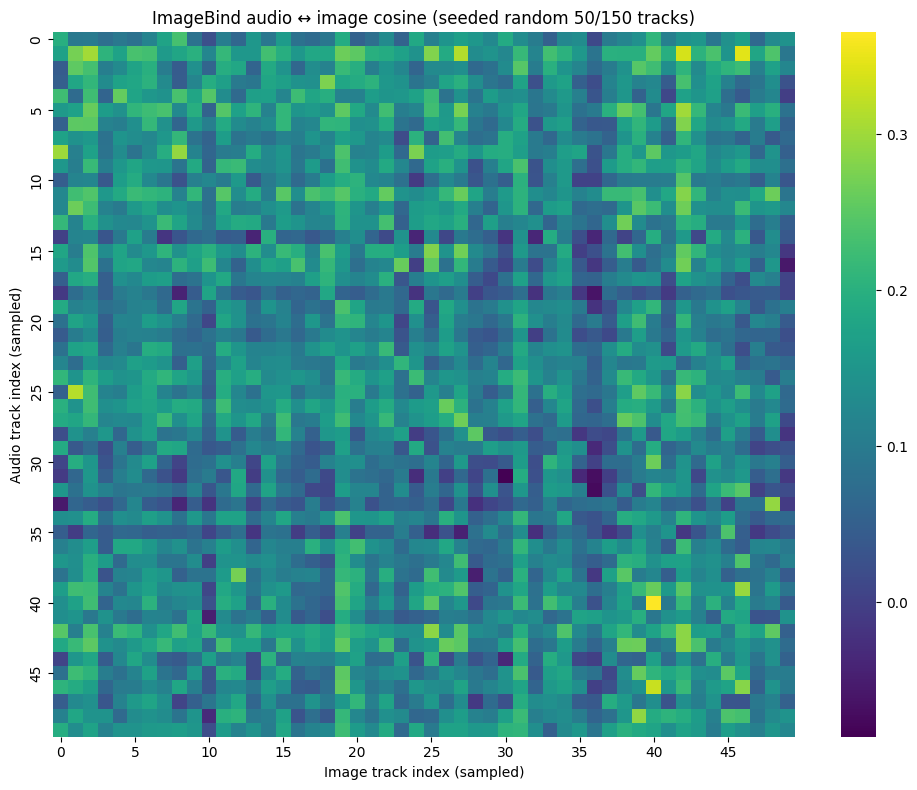

PLOT 2  |  Audio ↔ Text cosine heatmap (ImageBind, same 50 tracks)
Same layout as PLOT 1 but the columns are now lyrics-derived text embeddings.

Expect this diagonal to be WEAKER than the audio-image one. Lyrics carry
sparser, more variable content than album art, so the model has less handle
on them. A visible-but-fainter diagonal is the normal outcome; a diagonal
that disappears entirely would suggest the lyrics embedding pipeline has
a row-alignment or content problem.



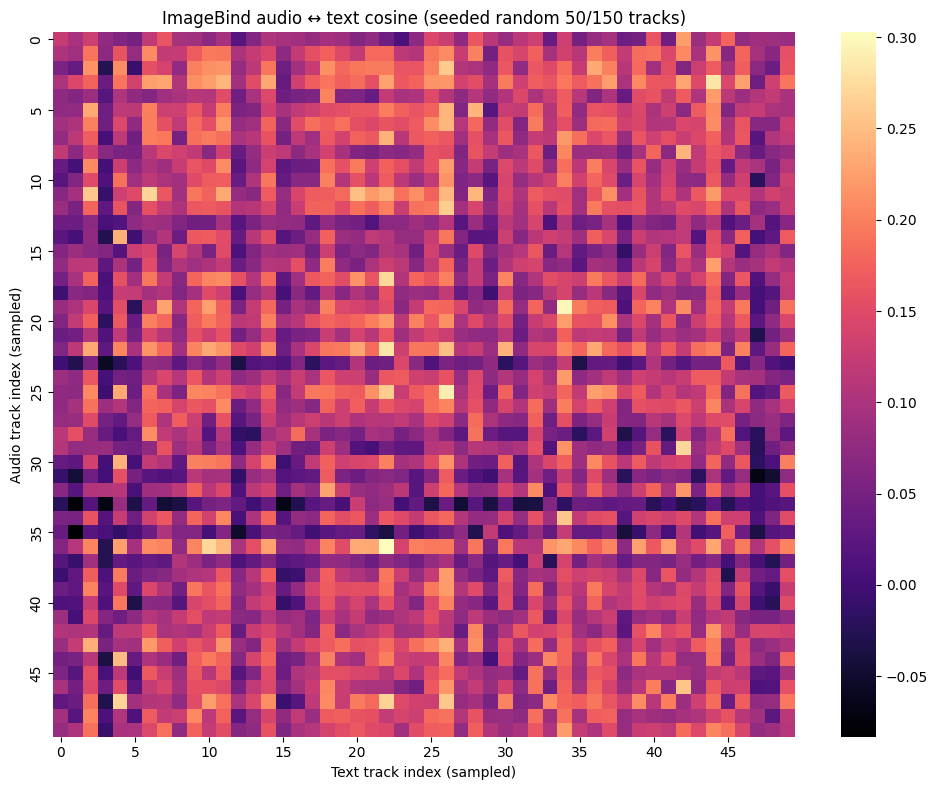

PLOT 3  |  Diagonal vs off-diagonal cosine — audio ↔ image
Diagonal (N=150 true pairs)        mean = 0.1796  std = 0.0666
Off-diagonal (N=22350 random pairs)  mean = 0.1208  std = 0.0652
Gap (diag − offdiag)                          = +0.0588

What you're looking at:
  The DIAGONAL distribution (red) is the cosine between the audio and
  the true partner for each of the 150 tracks.
  The OFF-DIAGONAL distribution (blue) is the cosine between that audio
  and every OTHER track's partner (22350 wrong pairs).
  Dashed verticals are the means of each distribution.

How to read it:
  - If the model has real semantic alignment, the red curve sits to the
    RIGHT of the blue curve.
  - The GAP between the two dashed lines is the signal the downstream
    retrieval metric exploits. A gap of +0.05 is detectable but weak;
    +0.10–0.20 is solid; +0.20+ is strong.
  - Heavy overlap (red curve nested inside blue) means the model cannot
    distinguish real pairs from random ones — retrieval will

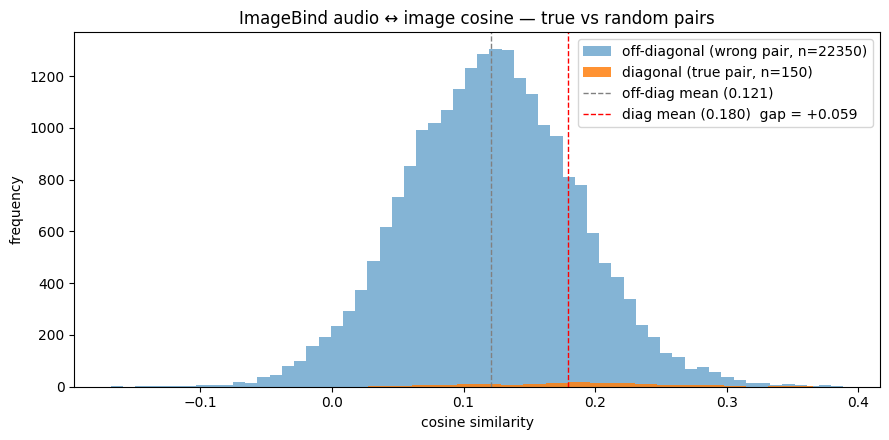

PLOT 4  |  Diagonal vs off-diagonal cosine — audio ↔ text
Diagonal (N=150 true pairs)        mean = 0.1382  std = 0.0605
Off-diagonal (N=22350 random pairs)  mean = 0.1080  std = 0.0605
Gap (diag − offdiag)                          = +0.0302

What you're looking at:
  The DIAGONAL distribution (red) is the cosine between the audio and
  the true partner for each of the 150 tracks.
  The OFF-DIAGONAL distribution (blue) is the cosine between that audio
  and every OTHER track's partner (22350 wrong pairs).
  Dashed verticals are the means of each distribution.

How to read it:
  - If the model has real semantic alignment, the red curve sits to the
    RIGHT of the blue curve.
  - The GAP between the two dashed lines is the signal the downstream
    retrieval metric exploits. A gap of +0.05 is detectable but weak;
    +0.10–0.20 is solid; +0.20+ is strong.
  - Heavy overlap (red curve nested inside blue) means the model cannot
    distinguish real pairs from random ones — retrieval will 

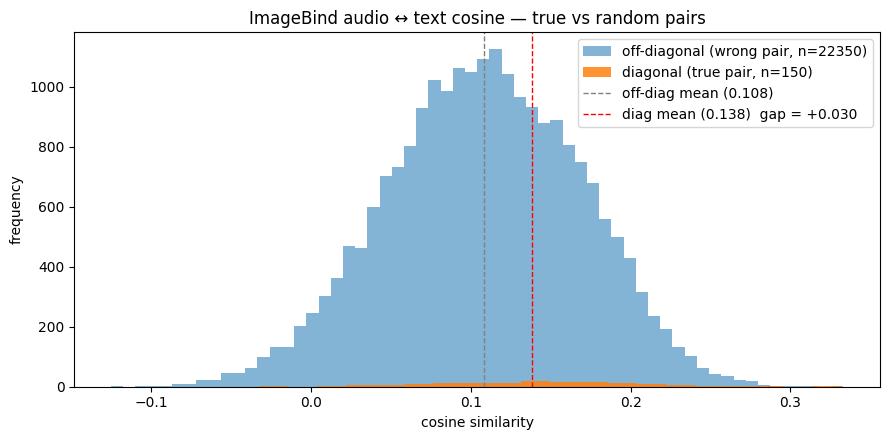

🎨 Plots 1–4 also saved to /content/drive/MyDrive/DL_Project_2026/04_Visual_Checks/05_2026-04-26_22-04/
   (the audio-image heatmap is additionally saved to 03_Final_Results/ for the report)


In [ ]:
# --- Defensive re-imports (in case Cell 8 is re-run after a kernel restart) ---
# This cell STILL depends on kernel state from Cells 2–7 (metadata, sim_audio_image,
# sim_audio_text, N, VIS_DIR, NOTEBOOK_ID, SEED, heatmap_results_png).
# Do Runtime → Run all if any of those are missing.
import os
from datetime import datetime
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# =====================================================================
# Cell 8 — Visual checks (render inline) + reader interpretation
# =====================================================================
# Every plot below is ALSO saved to 04_Visual_Checks/05_{timestamp}/ for
# the report, but we render inline first so you can read and interpret
# them as the notebook runs.

stamp = datetime.now().strftime("%Y-%m-%d_%H-%M")
vis_out = os.path.join(VIS_DIR, f"{NOTEBOOK_ID}_{stamp}")
os.makedirs(vis_out, exist_ok=True)

rng = np.random.RandomState(SEED)
idx = rng.choice(N, size=50, replace=False)

# ------------------------------------------------------------
# PLOT 1 — Audio ↔ Image cosine heatmap (ImageBind, 50 tracks)
# ------------------------------------------------------------
print("=" * 72)
print("PLOT 1  |  Audio ↔ Image cosine heatmap (ImageBind, 50/{} tracks)".format(N))
print("=" * 72)
print(
    "What you're looking at:\n"
    "  Rows = audio queries.  Cols = image candidates.\n"
    "  Cell (i, j) = cosine between audio_ib[i] and image_ib[j] for the same\n"
    "  50-track random sample.\n"
    "\n"
    "How to read it:\n"
    "  - The DIAGONAL (i = j) is the cosine for TRUE pairs (same track).\n"
    "  - Off-diagonal is MISMATCHED pairs (audio of track A vs image of track B).\n"
    "  - Brighter yellow = higher cosine.\n"
    "\n"
    "Healthy signal: a visible yellow diagonal stripe on a darker background.\n"
    "Pathology: uniform color, bright vertical/horizontal stripes (a track that\n"
    "'matches everything' usually indicates a near-zero or degenerate embedding),\n"
    "or a diagonal DARKER than the surroundings (model is actively wrong).\n"
)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(sim_audio_image[np.ix_(idx, idx)], cmap="viridis", cbar=True,
            xticklabels=5, yticklabels=5, ax=ax)
ax.set_title(f"ImageBind audio ↔ image cosine (seeded random 50/{N} tracks)")
ax.set_xlabel("Image track index (sampled)")
ax.set_ylabel("Audio track index (sampled)")
fig.tight_layout()
fig.savefig(heatmap_results_png, dpi=150)
fig.savefig(os.path.join(vis_out, "similarity_heatmap_av.png"), dpi=150)
plt.show()
plt.close(fig)

# ------------------------------------------------------------
# PLOT 2 — Audio ↔ Text cosine heatmap (ImageBind, same 50)
# ------------------------------------------------------------
print("=" * 72)
print("PLOT 2  |  Audio ↔ Text cosine heatmap (ImageBind, same 50 tracks)")
print("=" * 72)
print(
    "Same layout as PLOT 1 but the columns are now lyrics-derived text embeddings.\n"
    "\n"
    "Expect this diagonal to be WEAKER than the audio-image one. Lyrics carry\n"
    "sparser, more variable content than album art, so the model has less handle\n"
    "on them. A visible-but-fainter diagonal is the normal outcome; a diagonal\n"
    "that disappears entirely would suggest the lyrics embedding pipeline has\n"
    "a row-alignment or content problem.\n"
)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(sim_audio_text[np.ix_(idx, idx)], cmap="magma", cbar=True,
            xticklabels=5, yticklabels=5, ax=ax)
ax.set_title(f"ImageBind audio ↔ text cosine (seeded random 50/{N} tracks)")
ax.set_xlabel("Text track index (sampled)")
ax.set_ylabel("Audio track index (sampled)")
fig.tight_layout()
fig.savefig(os.path.join(vis_out, "similarity_heatmap_at.png"), dpi=150)
plt.show()
plt.close(fig)

# ------------------------------------------------------------
# PLOTS 3 & 4 — Diagonal vs off-diagonal distributions
# ------------------------------------------------------------
def _diag_offdiag(sim):
    d = np.diag(sim)
    mask = ~np.eye(sim.shape[0], dtype=bool)
    return d, sim[mask]

for plot_no, name, sim, outname in [
    (3, "audio ↔ image",  sim_audio_image,  "diag_vs_offdiag_av.png"),
    (4, "audio ↔ text",   sim_audio_text,   "diag_vs_offdiag_at.png"),
]:
    diag, offd = _diag_offdiag(sim)
    gap = diag.mean() - offd.mean()

    print("=" * 72)
    print(f"PLOT {plot_no}  |  Diagonal vs off-diagonal cosine — {name}")
    print("=" * 72)
    print(
        f"Diagonal (N={len(diag)} true pairs)        mean = {diag.mean():.4f}  std = {diag.std():.4f}\n"
        f"Off-diagonal (N={len(offd)} random pairs)  mean = {offd.mean():.4f}  std = {offd.std():.4f}\n"
        f"Gap (diag − offdiag)                          = {gap:+.4f}\n"
        "\n"
        "What you're looking at:\n"
        "  The DIAGONAL distribution (red) is the cosine between the audio and\n"
        "  the true partner for each of the {} tracks.\n"
        "  The OFF-DIAGONAL distribution (blue) is the cosine between that audio\n"
        "  and every OTHER track's partner ({} wrong pairs).\n"
        "  Dashed verticals are the means of each distribution.\n"
        "\n"
        "How to read it:\n"
        "  - If the model has real semantic alignment, the red curve sits to the\n"
        "    RIGHT of the blue curve.\n"
        "  - The GAP between the two dashed lines is the signal the downstream\n"
        "    retrieval metric exploits. A gap of +0.05 is detectable but weak;\n"
        "    +0.10–0.20 is solid; +0.20+ is strong.\n"
        "  - Heavy overlap (red curve nested inside blue) means the model cannot\n"
        "    distinguish real pairs from random ones — retrieval will be near chance.\n"
        .format(len(diag), len(offd))
    )

    fig, ax = plt.subplots(figsize=(9, 4.5))
    ax.hist(offd, bins=60, alpha=0.55, label=f"off-diagonal (wrong pair, n={len(offd)})")
    ax.hist(diag, bins=20, alpha=0.85, label=f"diagonal (true pair, n={len(diag)})")
    ax.axvline(offd.mean(), color="grey", linestyle="--", linewidth=1,
               label=f"off-diag mean ({offd.mean():.3f})")
    ax.axvline(diag.mean(), color="red",  linestyle="--", linewidth=1,
               label=f"diag mean ({diag.mean():.3f})  gap = {gap:+.3f}")
    ax.set_title(f"ImageBind {name} cosine — true vs random pairs")
    ax.set_xlabel("cosine similarity")
    ax.set_ylabel("frequency")
    ax.legend()
    fig.tight_layout()
    fig.savefig(os.path.join(vis_out, outname), dpi=150)
    plt.show()
    plt.close(fig)

print("=" * 72)
print(f"🎨 Plots 1–4 also saved to {vis_out}/")
print("   (the audio-image heatmap is additionally saved to 03_Final_Results/ for the report)")


## Additional interpretive visualizations

Cell 10 below turns the four CSVs produced earlier (category leaderboard,
retrieval recall, generalist-vs-specialist, the full similarity report) into
four reader-friendly charts. Each chart is prefaced with what it shows, how to
read it, and what counts as a "healthy" vs "concerning" pattern for this
project's generalist-vs-specialist research question.


PLOT 5  |  Master congruence by emotion category
What you're looking at:
  One bar per emotion_category, sorted descending by mean master_congruence.
  master_congruence = mean(congruence_audio_visual, congruence_audio_lyric).
  Error bars = 1 standard deviation within the category.
  Numeric annotation above each bar = track count in that category.

How to read it:
  - HIGHER bars = categories where ImageBind aligns audio, image, and
    lyrics into a coherent multimodal representation.
  - LOWER bars = categories where the three modalities disagree — either
    because the emotion is inherently ambiguous across modalities, OR
    because ImageBind's pretraining underrepresented that emotional content.
  - LARGE error bars = category is heterogeneous; a few tracks may be
    pulling the mean.
  - SMALL n (<5) = treat the bar skeptically; not enough tracks to trust.

Research-question read: the spread ACROSS categories is the interesting
signal. A flat chart means the generalist is equ

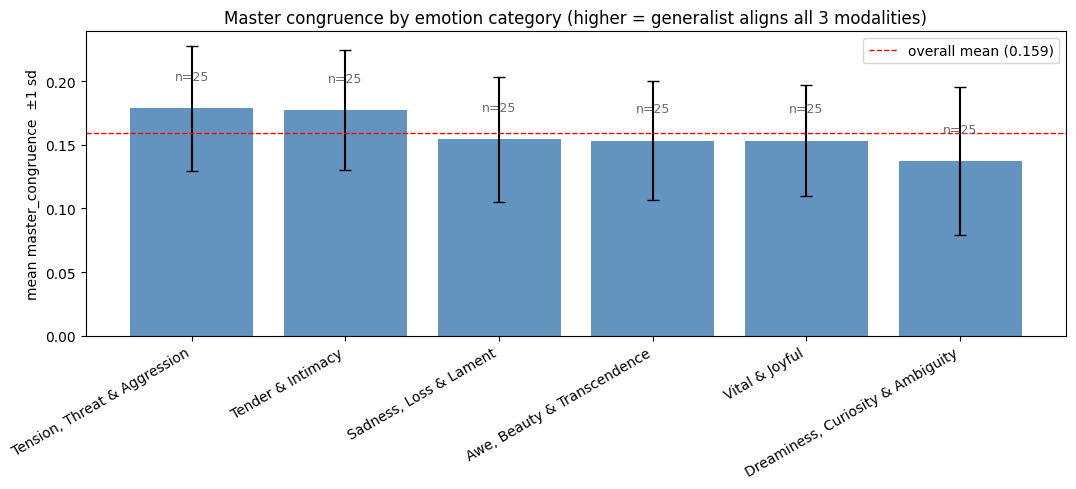

PLOT 6  |  Cross-modal retrieval Recall@{1, 5, 10}
What you're looking at:
  Four retrieval directions × three K values = 12 bars, grouped by direction.
  Dashed grey lines = chance baseline (K / N = 0.007, 0.033, 0.067).
  Each bar is labeled with its exact recall value.

How to read it:
  - R@K = fraction of queries where the TRUE partner is in the top-K
    ranked candidates. N = 150, so R@1 chance is 0.007, R@10 chance is 0.067.
  - Any bar far above its chance line means the model is doing real work.
  - Symmetric directions (audio→image vs image→audio) should be within
    a few points of each other. Big asymmetries usually reflect one
    modality being "tighter" than the other — e.g., audio clustering
    more than images, which makes audio→X harder.
  - R@10 approaching 1.0 means the model nearly always puts the right
    partner in the top 10 — strong retrieval performance.
  - R@1 << R@10 is normal; finding the EXACT right partner is harder
    than finding it among ten cand

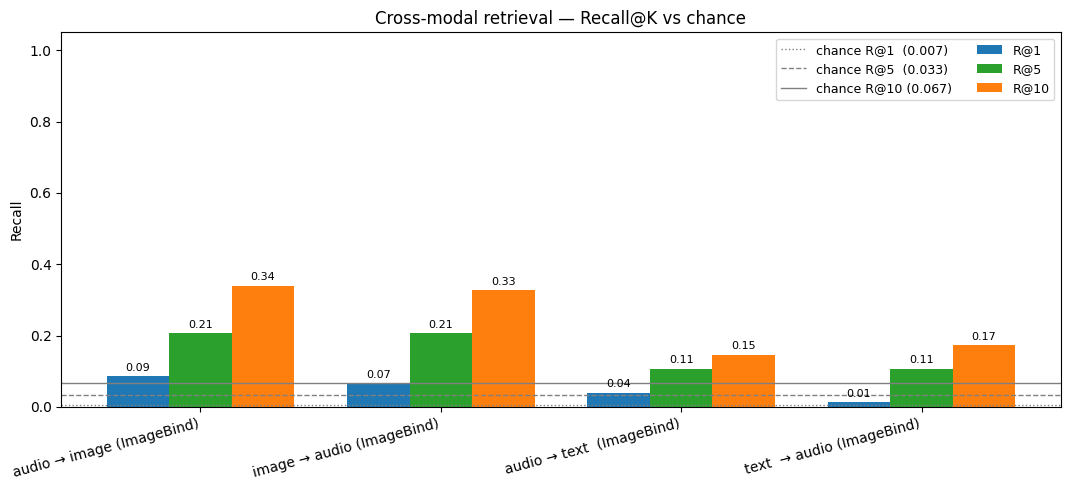

PLOT 7  |  Generalist vs specialist — CKA / RSA / Procrustes per modality
What you're looking at:
  Three modality pairs (audio: IB vs MERT, image: IB vs CLIP, text: IB vs CLAP)
  × three similarity metrics (CKA_linear, RSA_spearman, Procrustes_R2).

What each metric means:
  - CKA_linear [0, 1]:    how similar the two spaces' INNER STRUCTURE is,
                          independent of rotation or scale. CKA=1 means
                          identical pairwise Gram matrices.
  - RSA_spearman [-1, 1]: rank correlation of PAIRWISE DISTANCES. Answers
                          'do both spaces agree on which points are nearer
                          than which others?' Robust to monotone distortion.
  - Procrustes_R2 [0, 1]: after PCA to common rank, how well does an
                          orthogonal rotation of one space fit the other?
                          1 = perfect rotation, 0 = no linear relationship.

How to read it:
  - For the generalist-vs-specialist research question, H

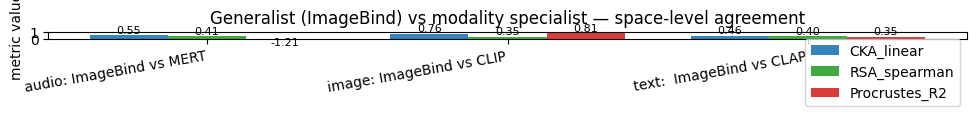

PLOT 8  |  Per-track congruence scatter — audio↔image vs audio↔lyrics
Pearson correlation between the two bridges: r = +0.255

What you're looking at:
  One dot per track (N = 150). X = audio↔image cosine (via ImageBind).
  Y = audio↔lyrics cosine (via ImageBind). Color = emotion_category.
  Dashed line = y = x reference; dotted lines = overall means on each axis.

How to read it:
  - STRONG positive correlation (r > 0.5): the two bridges tell the same
    story. Tracks the model aligns well audio-visually it also aligns
    well audio-lyrically. Multimodal coherence is strong.
  - WEAK or zero correlation: the bridges disagree. A track can land in
    the upper-left (lyrics match audio but image doesn't) or lower-right
    (image matches audio but lyrics don't) — both are 'dissonance' cases
    but of different kinds.
  - CATEGORY CLUSTERS: if dots of the same color group together, that
    emotion category has a characteristic congruence signature. Color
    mixing means the emotion 

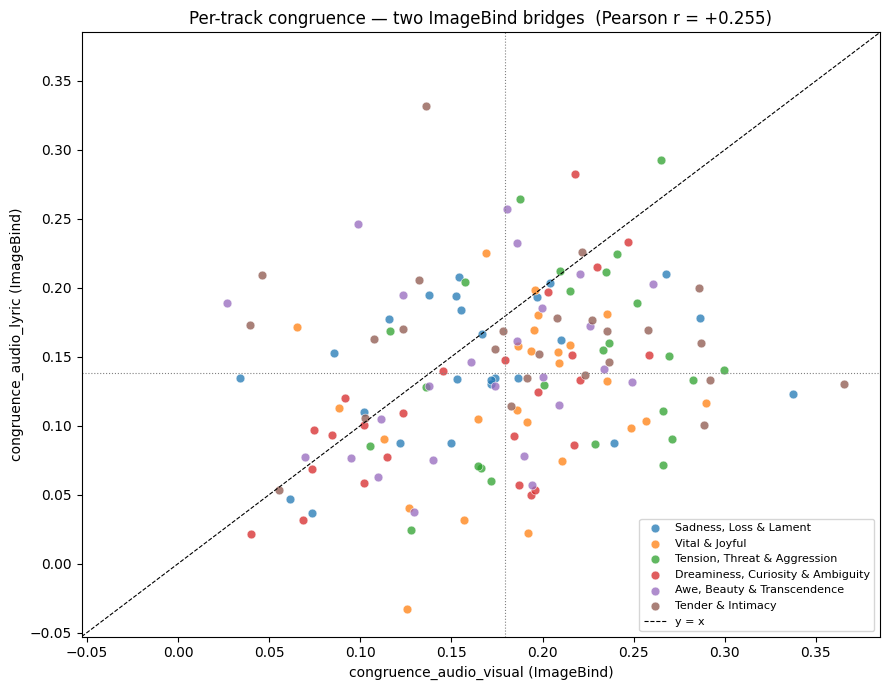

🎨 Interpretive plots (5–8) also saved to /content/drive/MyDrive/DL_Project_2026/04_Visual_Checks/05_2026-04-26_22-04/
✅ Notebook 05 complete.
   Downstream contract: notebook 06 reads
     - 03_Final_Results/final_similarity_report.csv (metadata + congruence_* columns)
     - 03_Final_Results/category_performance.csv
     - 03_Final_Results/subcategory_performance.csv


In [ ]:
# --- Defensive re-imports (in case Cell 10 is re-run after a kernel restart) ---
# Cell 10 depends on kernel state from Cells 2–8: metadata, cat_perf, gen_vs_spec,
# retrieval_df, vis_out, N. Do Runtime → Run all if any of those are missing.
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# =====================================================================
# Cell 10 — Interpretive plots built from Cells 4–7 outputs
# =====================================================================

# ------------------------------------------------------------
# PLOT 5 — Category-level master_congruence bar chart
# ------------------------------------------------------------
print("=" * 72)
print("PLOT 5  |  Master congruence by emotion category")
print("=" * 72)
print(
    "What you're looking at:\n"
    "  One bar per emotion_category, sorted descending by mean master_congruence.\n"
    "  master_congruence = mean(congruence_audio_visual, congruence_audio_lyric).\n"
    "  Error bars = 1 standard deviation within the category.\n"
    "  Numeric annotation above each bar = track count in that category.\n"
    "\n"
    "How to read it:\n"
    "  - HIGHER bars = categories where ImageBind aligns audio, image, and\n"
    "    lyrics into a coherent multimodal representation.\n"
    "  - LOWER bars = categories where the three modalities disagree — either\n"
    "    because the emotion is inherently ambiguous across modalities, OR\n"
    "    because ImageBind's pretraining underrepresented that emotional content.\n"
    "  - LARGE error bars = category is heterogeneous; a few tracks may be\n"
    "    pulling the mean.\n"
    "  - SMALL n (<5) = treat the bar skeptically; not enough tracks to trust.\n"
    "\n"
    "Research-question read: the spread ACROSS categories is the interesting\n"
    "signal. A flat chart means the generalist is equally good (or bad) at\n"
    "every emotion — it has no preferred emotional vocabulary. A spiky chart\n"
    "means the generalist has genuine emotional biases baked in.\n"
)

cat_plot = cat_perf.sort_values("master_congruence_mean", ascending=False).copy()
fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(cat_plot))
bars = ax.bar(x, cat_plot["master_congruence_mean"],
              yerr=cat_plot["master_congruence_std"],
              color="steelblue", alpha=0.85, capsize=4)
# Annotate each bar with its track count
for xi, (val, n) in enumerate(zip(cat_plot["master_congruence_mean"],
                                   cat_plot["master_congruence_count"])):
    ax.text(xi, val + 0.02, f"n={int(n)}", ha="center", va="bottom",
            fontsize=9, color="dimgrey")
ax.axhline(metadata["master_congruence"].mean(), color="red", linestyle="--",
           linewidth=1, label=f"overall mean ({metadata['master_congruence'].mean():.3f})")
ax.set_xticks(x)
ax.set_xticklabels(cat_plot["emotion_category"], rotation=30, ha="right")
ax.set_ylabel("mean master_congruence  ±1 sd")
ax.set_title("Master congruence by emotion category (higher = generalist aligns all 3 modalities)")
ax.legend()
fig.tight_layout()
fig.savefig(os.path.join(vis_out, "category_master_congruence.png"), dpi=150)
plt.show()
plt.close(fig)

# ------------------------------------------------------------
# PLOT 6 — Cross-modal retrieval Recall@K
# ------------------------------------------------------------
print("=" * 72)
print("PLOT 6  |  Cross-modal retrieval Recall@{1, 5, 10}")
print("=" * 72)
print(
    "What you're looking at:\n"
    "  Four retrieval directions × three K values = 12 bars, grouped by direction.\n"
    "  Dashed grey lines = chance baseline (K / N = {:.3f}, {:.3f}, {:.3f}).\n"
    "  Each bar is labeled with its exact recall value.\n"
    "\n"
    "How to read it:\n"
    "  - R@K = fraction of queries where the TRUE partner is in the top-K\n"
    "    ranked candidates. N = {}, so R@1 chance is {:.3f}, R@10 chance is {:.3f}.\n"
    "  - Any bar far above its chance line means the model is doing real work.\n"
    "  - Symmetric directions (audio→image vs image→audio) should be within\n"
    "    a few points of each other. Big asymmetries usually reflect one\n"
    "    modality being \"tighter\" than the other — e.g., audio clustering\n"
    "    more than images, which makes audio→X harder.\n"
    "  - R@10 approaching 1.0 means the model nearly always puts the right\n"
    "    partner in the top 10 — strong retrieval performance.\n"
    "  - R@1 << R@10 is normal; finding the EXACT right partner is harder\n"
    "    than finding it among ten candidates.\n".format(
        1.0 / N, 5.0 / N, 10.0 / N, N, 1.0 / N, 10.0 / N
    )
)

directions = retrieval_df["query_target"].tolist()
x = np.arange(len(directions))
width = 0.26
fig, ax = plt.subplots(figsize=(11, 5))
b1 = ax.bar(x - width, retrieval_df["R@1"],  width, label="R@1",  color="#1f77b4")
b2 = ax.bar(x,         retrieval_df["R@5"],  width, label="R@5",  color="#2ca02c")
b3 = ax.bar(x + width, retrieval_df["R@10"], width, label="R@10", color="#ff7f0e")
for bars in (b1, b2, b3):
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h + 0.01,
                f"{h:.2f}", ha="center", va="bottom", fontsize=8)
ax.axhline(1.0 / N,  color="grey", linestyle=":", linewidth=1, label=f"chance R@1  ({1.0/N:.3f})")
ax.axhline(5.0 / N,  color="grey", linestyle="--", linewidth=1, label=f"chance R@5  ({5.0/N:.3f})")
ax.axhline(10.0 / N, color="grey", linestyle="-",  linewidth=1, label=f"chance R@10 ({10.0/N:.3f})")
ax.set_xticks(x)
ax.set_xticklabels(directions, rotation=15, ha="right")
ax.set_ylabel("Recall")
ax.set_ylim(0, 1.05)
ax.set_title("Cross-modal retrieval — Recall@K vs chance")
ax.legend(loc="upper right", ncol=2, fontsize=9)
fig.tight_layout()
fig.savefig(os.path.join(vis_out, "retrieval_recall_bar.png"), dpi=150)
plt.show()
plt.close(fig)

# ------------------------------------------------------------
# PLOT 7 — Generalist vs specialist (CKA / RSA / Procrustes)
# ------------------------------------------------------------
print("=" * 72)
print("PLOT 7  |  Generalist vs specialist — CKA / RSA / Procrustes per modality")
print("=" * 72)
print(
    "What you're looking at:\n"
    "  Three modality pairs (audio: IB vs MERT, image: IB vs CLIP, text: IB vs CLAP)\n"
    "  × three similarity metrics (CKA_linear, RSA_spearman, Procrustes_R2).\n"
    "\n"
    "What each metric means:\n"
    "  - CKA_linear [0, 1]:    how similar the two spaces' INNER STRUCTURE is,\n"
    "                          independent of rotation or scale. CKA=1 means\n"
    "                          identical pairwise Gram matrices.\n"
    "  - RSA_spearman [-1, 1]: rank correlation of PAIRWISE DISTANCES. Answers\n"
    "                          'do both spaces agree on which points are nearer\n"
    "                          than which others?' Robust to monotone distortion.\n"
    "  - Procrustes_R2 [0, 1]: after PCA to common rank, how well does an\n"
    "                          orthogonal rotation of one space fit the other?\n"
    "                          1 = perfect rotation, 0 = no linear relationship.\n"
    "\n"
    "How to read it:\n"
    "  - For the generalist-vs-specialist research question, HIGHER bars mean the\n"
    "    generalist is essentially reproducing what the specialist does — a small\n"
    "    win for generalist models (one model replaces three).\n"
    "  - LOWER bars mean the generalist and specialist organize the data\n"
    "    DIFFERENTLY — a win for specialists, since you'd lose information by\n"
    "    discarding them.\n"
    "  - Typical ranges: CKA 0.3–0.7 for related-but-distinct pretraining;\n"
    "    CKA > 0.8 means the spaces are effectively interchangeable; CKA < 0.2\n"
    "    means they're unrelated.\n"
    "  - Compare the three modalities: the modality with the LOWEST bars is\n"
    "    where the specialist retains the most unique information.\n"
)

metrics = ["CKA_linear", "RSA_spearman", "Procrustes_R2"]
x = np.arange(len(gen_vs_spec))
width = 0.26
fig, ax = plt.subplots(figsize=(10, 5))
colors = ["#1f77b4", "#2ca02c", "#d62728"]
for i, (m, col) in enumerate(zip(metrics, colors)):
    bars = ax.bar(x + (i - 1) * width, gen_vs_spec[m], width, label=m, color=col, alpha=0.9)
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h + 0.01,
                f"{h:.2f}", ha="center", va="bottom", fontsize=8)
ax.set_xticks(x)
ax.set_xticklabels(gen_vs_spec["comparison"], rotation=10, ha="right")
ax.set_ylim(0, 1.05)
ax.set_ylabel("metric value")
ax.set_title("Generalist (ImageBind) vs modality specialist — space-level agreement")
ax.legend(loc="upper right")
fig.tight_layout()
fig.savefig(os.path.join(vis_out, "generalist_vs_specialist_bar.png"), dpi=150)
plt.show()
plt.close(fig)

# ------------------------------------------------------------
# PLOT 8 — Congruence scatter (audio-visual vs audio-lyric)
# ------------------------------------------------------------
print("=" * 72)
print("PLOT 8  |  Per-track congruence scatter — audio↔image vs audio↔lyrics")
print("=" * 72)
pearson_r = metadata[["congruence_audio_visual", "congruence_audio_lyric"]].corr().iloc[0, 1]
print(
    f"Pearson correlation between the two bridges: r = {pearson_r:+.3f}\n"
    "\n"
    "What you're looking at:\n"
    "  One dot per track (N = {}). X = audio↔image cosine (via ImageBind).\n"
    "  Y = audio↔lyrics cosine (via ImageBind). Color = emotion_category.\n"
    "  Dashed line = y = x reference; dotted lines = overall means on each axis.\n"
    "\n"
    "How to read it:\n"
    "  - STRONG positive correlation (r > 0.5): the two bridges tell the same\n"
    "    story. Tracks the model aligns well audio-visually it also aligns\n"
    "    well audio-lyrically. Multimodal coherence is strong.\n"
    "  - WEAK or zero correlation: the bridges disagree. A track can land in\n"
    "    the upper-left (lyrics match audio but image doesn't) or lower-right\n"
    "    (image matches audio but lyrics don't) — both are 'dissonance' cases\n"
    "    but of different kinds.\n"
    "  - CATEGORY CLUSTERS: if dots of the same color group together, that\n"
    "    emotion category has a characteristic congruence signature. Color\n"
    "    mixing means the emotion category isn't predictive of multimodal\n"
    "    alignment — the spread within a category is as big as the spread\n"
    "    across categories.\n"
    "  - OUTLIERS in the lower-left are your top 'dissonance cases' from Cell 7.\n".format(N)
)

fig, ax = plt.subplots(figsize=(9, 7))
categories = metadata["emotion_category"].unique()
palette = sns.color_palette("tab10", n_colors=len(categories))
for cat, col in zip(categories, palette):
    sub = metadata[metadata["emotion_category"] == cat]
    ax.scatter(sub["congruence_audio_visual"], sub["congruence_audio_lyric"],
               label=cat, color=col, alpha=0.75, s=40, edgecolors="white", linewidths=0.5)

# y = x reference
lo = min(metadata["congruence_audio_visual"].min(), metadata["congruence_audio_lyric"].min()) - 0.02
hi = max(metadata["congruence_audio_visual"].max(), metadata["congruence_audio_lyric"].max()) + 0.02
ax.plot([lo, hi], [lo, hi], linestyle="--", color="black", linewidth=0.8, label="y = x")
ax.axvline(metadata["congruence_audio_visual"].mean(), linestyle=":", color="grey", linewidth=0.8)
ax.axhline(metadata["congruence_audio_lyric"].mean(),  linestyle=":", color="grey", linewidth=0.8)

ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)
ax.set_xlabel("congruence_audio_visual (ImageBind)")
ax.set_ylabel("congruence_audio_lyric (ImageBind)")
ax.set_title(f"Per-track congruence — two ImageBind bridges  (Pearson r = {pearson_r:+.3f})")
ax.legend(loc="lower right", fontsize=8, ncol=1)
fig.tight_layout()
fig.savefig(os.path.join(vis_out, "congruence_scatter.png"), dpi=150)
plt.show()
plt.close(fig)

print("=" * 72)
print(f"🎨 Interpretive plots (5–8) also saved to {vis_out}/")
print("✅ Notebook 05 complete.")
print("   Downstream contract: notebook 06 reads")
print("     - 03_Final_Results/final_similarity_report.csv (metadata + congruence_* columns)")
print("     - 03_Final_Results/category_performance.csv")
print("     - 03_Final_Results/subcategory_performance.csv")
